Data columns:
['Company', 'Debt_Asset_Ratio', 'Gross_Profit_Ratio', 'Net_Profit_Ratio']

First 5 rows of data:
      Company  Debt_Asset_Ratio  Gross_Profit_Ratio  Net_Profit_Ratio
0     Yonghui             64.82               21.73              1.65
1      Suning             79.11               14.82              0.43
2  Wangfujing             41.95               38.27              5.18
3     Bubugao             68.33               22.45             -2.11
4   JiajiaYue             62.50               25.62              2.77

Cleaned data saved to: /Users/azamalfoy/Downloads/UNI/Acc102 mini assignment/retail_finance_2024_cleaned.csv


/var/folders/mt/8js2dy4d31vfxzqx6d8_ddhh0000gn/T/ipykernel_72701/717818343.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Company', y='Gross_Profit_Ratio', data=df, palette='Blues_d')


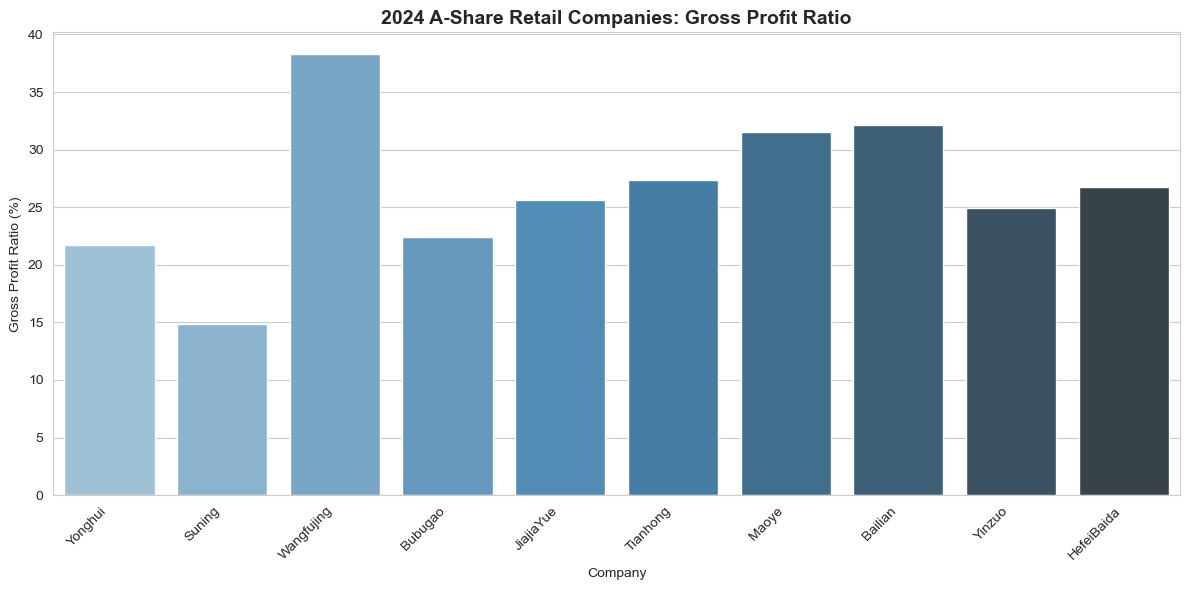

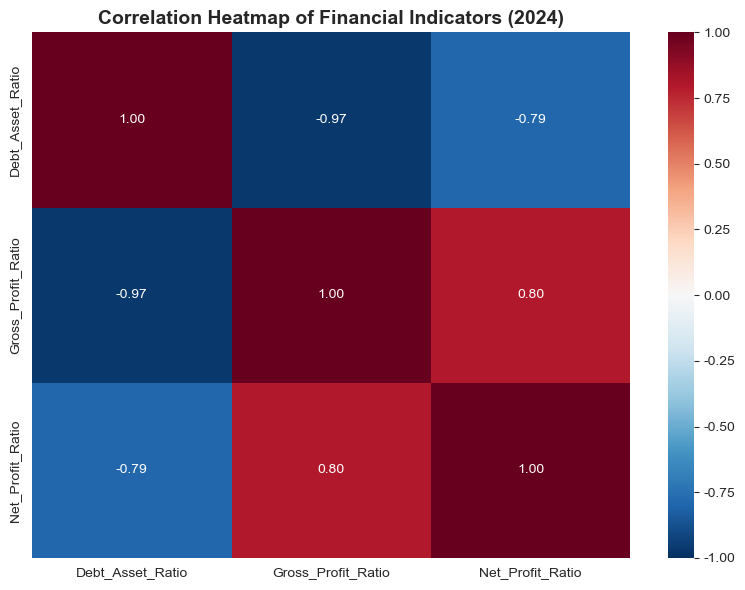

/var/folders/mt/8js2dy4d31vfxzqx6d8_ddhh0000gn/T/ipykernel_72701/717818343.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Company', y='Debt_Asset_Ratio', data=df, palette='Reds_d', ax=ax1)
/var/folders/mt/8js2dy4d31vfxzqx6d8_ddhh0000gn/T/ipykernel_72701/717818343.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Company', y='Net_Profit_Ratio', data=df, palette='Greens_d', ax=ax2)


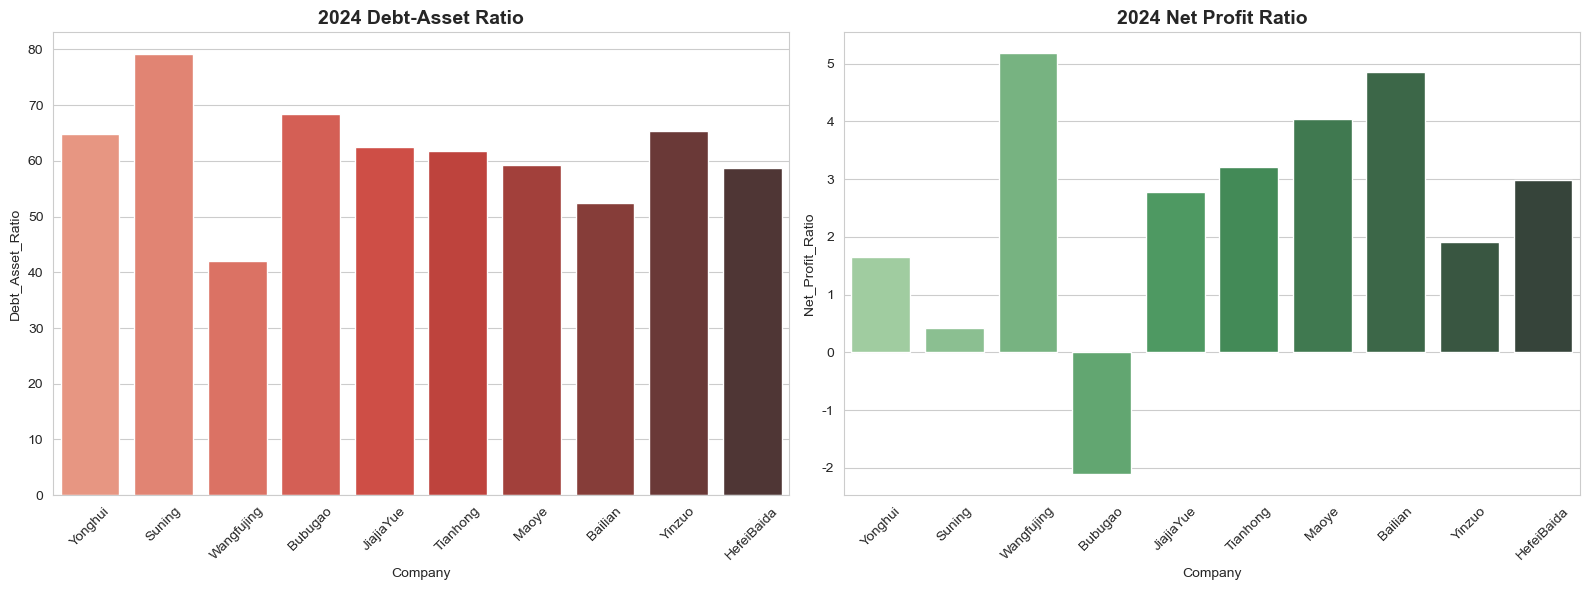


=== Key Analysis Results ===
Average Debt-Asset Ratio: 61.42%
Average Gross Profit Ratio: 26.56%
Average Net Profit Ratio: 2.5%

Company with highest gross profit ratio: Wangfujing
Company with lowest debt-asset ratio: Wangfujing
Company with highest net profit ratio: Wangfujing


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set font to display text normally
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ---------------------- Read Data ----------------------
file_path = "/Users/azamalfoy/Downloads/UNI/Acc102 mini assignment/retail_finance_2024_raw.csv"
df = pd.read_csv(file_path)

print("Data columns:")
print(df.columns.tolist())
print("\nFirst 5 rows of data:")
print(df.head())

# ---------------------- Data Cleaning ----------------------
# Remove missing values and duplicate rows
df = df.dropna()
df = df.drop_duplicates()

# Convert financial indicators to numeric type
df['Debt_Asset_Ratio'] = pd.to_numeric(df['Debt_Asset_Ratio'], errors='coerce')
df['Gross_Profit_Ratio'] = pd.to_numeric(df['Gross_Profit_Ratio'], errors='coerce')
df['Net_Profit_Ratio'] = pd.to_numeric(df['Net_Profit_Ratio'], errors='coerce')

# Filter out unreasonable outliers
df = df[(df['Debt_Asset_Ratio'] >= 0) & (df['Debt_Asset_Ratio'] <= 100)]
df = df[(df['Gross_Profit_Ratio'] >= 0) & (df['Gross_Profit_Ratio'] <= 100)]
df = df[(df['Net_Profit_Ratio'] >= -10) & (df['Net_Profit_Ratio'] <= 100)]

# Save cleaned data
cleaned_path = "/Users/azamalfoy/Downloads/UNI/Acc102 mini assignment/retail_finance_2024_cleaned.csv"
df.to_csv(cleaned_path, index=False)
print(f"\nCleaned data saved to: {cleaned_path}")

# ---------------------- Data Visualization ----------------------
sns.set_style('whitegrid')

# 1. Gross Profit Ratio Bar Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Company', y='Gross_Profit_Ratio', data=df, palette='Blues_d')
plt.title('2024 A-Share Retail Companies: Gross Profit Ratio', fontsize=14, fontweight='bold')
plt.xlabel('Company')
plt.ylabel('Gross Profit Ratio (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("/Users/azamalfoy/Downloads/UNI/Acc102 mini assignment/Gross_Profit_Ratio_Bar.png", dpi=300)
plt.show()

# 2. Correlation Heatmap
corr = df[['Debt_Asset_Ratio', 'Gross_Profit_Ratio', 'Net_Profit_Ratio']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Heatmap of Financial Indicators (2024)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/Users/azamalfoy/Downloads/UNI/Acc102 mini assignment/Financial_Indicators_Correlation.png", dpi=300)
plt.show()

# 3. Debt-Asset Ratio & Net Profit Ratio Subplot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x='Company', y='Debt_Asset_Ratio', data=df, palette='Reds_d', ax=ax1)
sns.barplot(x='Company', y='Net_Profit_Ratio', data=df, palette='Greens_d', ax=ax2)

ax1.set_title('2024 Debt-Asset Ratio', fontsize=14, fontweight='bold')
ax2.set_title('2024 Net Profit Ratio', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("/Users/azamalfoy/Downloads/UNI/Acc102 mini assignment/Debt_Asset_Net_Profit_Subplot.png", dpi=300)
plt.show()

# ---------------------- Summary Statistics ----------------------
print("\n=== Key Analysis Results ===")

# Calculate average values
avg_debt = round(df['Debt_Asset_Ratio'].mean(), 2)
avg_gross = round(df['Gross_Profit_Ratio'].mean(), 2)
avg_net = round(df['Net_Profit_Ratio'].mean(), 2)

print(f"Average Debt-Asset Ratio: {avg_debt}%")
print(f"Average Gross Profit Ratio: {avg_gross}%")
print(f"Average Net Profit Ratio: {avg_net}%")

# Identify companies with best performance
highest_gross = df.loc[df['Gross_Profit_Ratio'].idxmax(), 'Company']
lowest_debt = df.loc[df['Debt_Asset_Ratio'].idxmin(), 'Company']
highest_net = df.loc[df['Net_Profit_Ratio'].idxmax(), 'Company']

print(f"\nCompany with highest gross profit ratio: {highest_gross}")
print(f"Company with lowest debt-asset ratio: {lowest_debt}")
print(f"Company with highest net profit ratio: {highest_net}")